In [3]:
from sklearn.datasets import make_blobs

# Generate synthetic data for clustering
X, y = make_blobs(n_samples=300, centers=3, cluster_std=0.60, random_state=42)
df_synthetic = pd.DataFrame(X, columns=['Feature 1', 'Feature 2'])

# Save the synthetic data to a CSV file
df_synthetic.to_csv('cluster_data.csv', index=False)

print('Generated and saved synthetic cluster_data.csv')

Generated and saved synthetic cluster_data.csv


In [4]:
pip install pandas numpy matplotlib scikit-learn

First 5 Rows:
   Feature 1  Feature 2
0  -7.155244  -7.390016
1  -7.395875  -7.110843
2  -2.015671   8.281780
3   4.509270   2.632436
4  -8.102502  -7.484961

Dataset Shape:
(300, 2)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Feature 1  300 non-null    float64
 1   Feature 2  300 non-null    float64
dtypes: float64(2)
memory usage: 4.8 KB
None


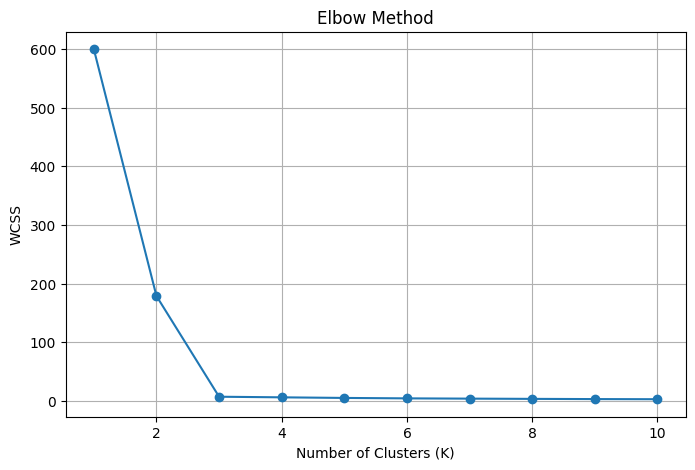


Clustered Data:
   Feature 1  Feature 2  Cluster
0  -7.155244  -7.390016        1
1  -7.395875  -7.110843        1
2  -2.015671   8.281780        0
3   4.509270   2.632436        2
4  -8.102502  -7.484961        1

Cluster Centroids:
[[-2.58361866  9.03185632]
 [-6.88217395 -6.94243433]
 [ 4.70421356  1.99562444]]

Silhouette Score: 0.909


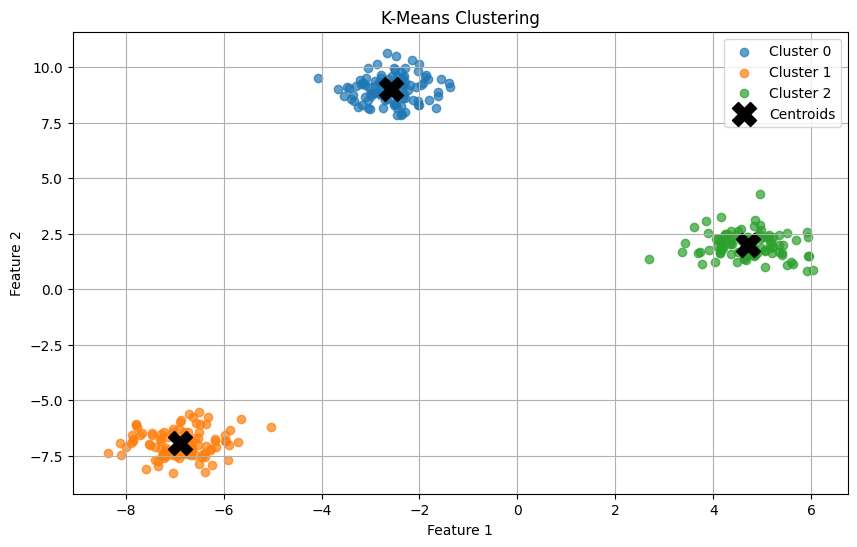


Cluster labels saved to clustered_output.csv

Number of Points in Each Cluster:
Cluster
1    100
0    100
2    100
Name: count, dtype: int64


In [5]:
# ==========================================
# K-MEANS CLUSTERING PROJECT
# ==========================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# ==========================================
# STEP 1: LOAD DATASET
# ==========================================

df = pd.read_csv("cluster_data.csv")

print("First 5 Rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nDataset Information:")
print(df.info())

# ==========================================
# STEP 2: SELECT FEATURES
# ==========================================

X = df[['Feature 1', 'Feature 2']]

# ==========================================
# STEP 3: FEATURE SCALING
# ==========================================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==========================================
# STEP 4: ELBOW METHOD
# ==========================================

wcss = []

for k in range(1, 11):

    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

# Plot Elbow Curve

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")

plt.grid(True)
plt.show()

# ==========================================
# STEP 5: TRAIN K-MEANS MODEL
# ==========================================

K = 3

kmeans = KMeans(
    n_clusters=K,
    init='k-means++',
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

# ==========================================
# STEP 6: ADD CLUSTER LABELS
# ==========================================

df['Cluster'] = clusters

print("\nClustered Data:")
print(df.head())

# ==========================================
# STEP 7: CENTROIDS
# ==========================================

centroids_scaled = kmeans.cluster_centers_

centroids = scaler.inverse_transform(centroids_scaled)

print("\nCluster Centroids:")
print(centroids)

# ==========================================
# STEP 8: SILHOUETTE SCORE
# ==========================================

score = silhouette_score(X_scaled, clusters)

print("\nSilhouette Score:", round(score, 3))

# ==========================================
# STEP 9: VISUALIZE CLUSTERS
# ==========================================

plt.figure(figsize=(10, 6))

colors = ['red', 'blue', 'green']

for i in range(K):

    plt.scatter(
        X[clusters == i]['Feature 1'],
        X[clusters == i]['Feature 2'],
        label=f'Cluster {i}',
        alpha=0.7
    )

# Plot Centroids

plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    s=300,
    marker='X',
    c='black',
    label='Centroids'
)

plt.title("K-Means Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.legend()
plt.grid(True)

plt.show()

# ==========================================
# STEP 10: SAVE RESULTS
# ==========================================

df.to_csv("clustered_output.csv", index=False)

print("\nCluster labels saved to clustered_output.csv")

# ==========================================
# STEP 11: CLUSTER STATISTICS
# ==========================================

print("\nNumber of Points in Each Cluster:")

print(df['Cluster'].value_counts())